# Лабораторная работа №2 — Временные ряды погоды

**Задача.** Восстановить аккуратный многомерный временной ряд погоды из «грязного» Excel-файла, проанализировать его и обучить три семейства деревьев предсказывать температуру на горизонт **168 часов (1 неделя)** вперёд.

**Источник.** `have_fun.xlsx` (3 листа: видимый и два скрытых).

**Города (после очистки названий):** Благовещенск, Геленджик, Москва, Находка, Санкт-Петербург, Сочи.

**Период данных:** 2019-01-01 – 2025-12-31 (почасовые наблюдения, 7 лет).

**План работы (по этапам).**

1. Доступ ко всем листам Excel (включая скрытые) — `openpyxl` + `pandas`.
2. Очистка и унификация: моджибейк, опечатки городов, смещённые таблицы, строковые NaN-сентинелы, категориальные строки в числовых колонках, выбросы, дубликаты, единый почасовой индекс, заполнение пропусков.
3. Анализ временного ряда: визуализации, STL-декомпозиция, ACF/PACF, ADF + KPSS, FFT, STFT-спектрограмма, вейвлет-скалограмма.
4. Feature engineering: лаги, скользящие статистики, циклические календарные признаки, OHE города; формирование выборок для recursive- и direct-стратегий.
5. Обучение и подбор гиперпараметров через `optuna`: `DecisionTreeRegressor`, `RandomForestRegressor`, `HistGradientBoostingRegressor`. Сравнение recursive- и direct-стратегий.
6. Оценка на тесте: WAPE, MAE, MAPE, directional accuracy, directional R²; разбивка по городам и по горизонтам; анализ остатков.

## 1. Доступ ко всем листам Excel-файла

In [1]:
from __future__ import annotations
import warnings, math, json, os, time, itertools
from pathlib import Path
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True
sns.set_palette("tab10")
RNG = 42
np.random.seed(RNG)

DATA_PATH = Path("have_fun.xlsx").resolve()
print("Файл:", DATA_PATH, "размер:", DATA_PATH.stat().st_size // 1024, "KB")

Файл: /Users/delusionn/prog/data-analysis-frameworks-course/lab2/have_fun.xlsx размер: 18301 KB


### 1.1. Состояние листов через `openpyxl`

Имена листов и сами текстовые значения в файле находятся в кодировке **cp1251**, но Excel/openpyxl интерпретируют их как latin-1 — получается классический *mojibake*. Чиним это перед чтением.

In [2]:
def fix_mojibake(value):
    """Latin-1 → cp1251. Молча возвращает исходное значение, если декодирование невозможно."""
    if not isinstance(value, str):
        return value
    try:
        return value.encode("latin-1").decode("cp1251")
    except (UnicodeDecodeError, UnicodeEncodeError):
        return value


# read_only=False даёт доступ к max_row / max_column / sheet_state без полной материализации.
wb = openpyxl.load_workbook(DATA_PATH, read_only=False, data_only=True)
print(f"Всего листов: {len(wb.sheetnames)}")
sheet_meta = []
for name in wb.sheetnames:
    ws = wb[name]
    sheet_meta.append({
        "raw_name": name,
        "decoded_name": fix_mojibake(name),
        "state": ws.sheet_state,
        "max_row": ws.max_row,
        "max_col": ws.max_column,
    })
sheet_meta_df = pd.DataFrame(sheet_meta)
sheet_meta_df


Всего листов: 8


,raw_name,decoded_name,state,max_row,max_col
0,Ëèñò1,Лист1,visible,125125,10
1,Лист1,Лист1,visible,1,1
2,ÌÀÈ,МАИ,visible,1,1
3,ýòî,это,visible,1,1
4,ÿ,я,visible,1,1
5,!,!,visible,1,1
6,Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû,Лист2_строковые_NaN_выбросы,hidden,125170,25
7,Ëèñò3_ñìåøàííûå_òèïû,Лист3_смешанные_типы,hidden,122737,10


Видно три листа с настоящими данными:
- `Лист1` (видимый),
- `Лист2_строковые_NaN_выбросы` (скрытый),
- `Лист3_смешанные_типы` (скрытый).

Остальные листы пусты или содержат «декорации» (`МАИ`, `это`, `я`, `!`).

In [3]:
data_sheets_raw = (
    sheet_meta_df.loc[
        (sheet_meta_df["max_row"] > 1) & (sheet_meta_df["max_col"] >= 10),
        "raw_name",
    ].tolist()
)
print("Будем читать листы:")
for s in data_sheets_raw:
    print(" -", repr(s), "->", repr(fix_mojibake(s)))

Будем читать листы:
 - 'Ëèñò1' -> 'Лист1'
 - 'Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû' -> 'Лист2_строковые_NaN_выбросы'
 - 'Ëèñò3_ñìåøàííûå_òèïû' -> 'Лист3_смешанные_типы'


### 1.2. Чтение всех листов через `pandas`

`sheet_name=None` сразу возвращает словарь всех листов. Никакой фильтрации по `visible` — нужно поднять и скрытые.

In [4]:
raw_sheets = pd.read_excel(DATA_PATH, sheet_name=None, engine="openpyxl")
sheet_diag = []
for name, df in raw_sheets.items():
    if df.empty:
        continue
    sheet_diag.append({
        "raw_name": name,
        "decoded_name": fix_mojibake(name),
        "rows": df.shape[0],
        "cols": df.shape[1],
        "n_full_empty": int(df.isna().all(axis=1).sum()),
        "dtypes": ", ".join(sorted({str(t) for t in df.dtypes})),
    })
sheet_diag_df = pd.DataFrame(sheet_diag).sort_values("rows", ascending=False)
sheet_diag_df

,raw_name,decoded_name,rows,cols,n_full_empty,dtypes
1,Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû,Лист2_строковые_NaN_выбросы,125169,25,2452,"datetime64[ns], float64, object"
0,Ëèñò1,Лист1,125124,10,0,"datetime64[ns], float64, int64, object"
2,Ëèñò3_ñìåøàííûå_òèïû,Лист3_смешанные_типы,122736,10,0,"datetime64[ns], float64, object"


Сводка подтверждает: сюжет про «грязные» листы реален — у второго листа аж **25 столбцов** (вместо ожидаемых 10 это почти наверняка значит «таблица съехала вправо»).

## 2. Очистка и унификация данных

Целевая схема:

| колонка | тип |
|---|---|
| `ds` | `datetime64[ns]` |
| `city` | `category` |
| `temperature_2m` | `float` |
| `relative_humidity_2m` | `float` |
| `precipitation` | `float` |
| `rain` | `float` |
| `snowfall` | `float` |
| `weathercode` | `float` |
| `wind_speed_10m` | `float` |
| `surface_pressure` | `float` |

Все листы должны быть приведены к этой схеме.

In [5]:
TARGET_COLS = [
    "temperature_2m", "relative_humidity_2m", "precipitation", "rain",
    "snowfall", "weathercode", "wind_speed_10m", "surface_pressure",
    "ds", "city",
]
NUMERIC_COLS = TARGET_COLS[:8]
print("Numeric:", NUMERIC_COLS)

Numeric: ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure']


### 2.1. Восстановление имён городов

Правила:
1. Чиним моджибейк (`encode latin-1` → `decode cp1251`).
2. Стандартизируем регистр и удаляем хвостовые/двойные буквы.
3. Сводим орфографические варианты («Сычи», «Соч», «Мосва», …) к каноническому имени.

In [6]:
CANONICAL_CITIES = [
    "Москва", "Санкт-Петербург", "Сочи", "Геленджик", "Благовещенск", "Находка",
]


def normalize_city(value):
    if not isinstance(value, str):
        return None
    text = fix_mojibake(value).strip().casefold()
    if not text:
        return None
    aliases = {
        "москва": "Москва",
        "мосва": "Москва",
        "москв": "Москва",
        "санкт-петербург": "Санкт-Петербург",
        "санкт петербург": "Санкт-Петербург",
        "спб": "Санкт-Петербург",
        "сочи": "Сочи",
        "сычи": "Сочи",
        "счи": "Сочи",
        "соч": "Сочи",
        "геленджик": "Геленджик",
        "геленджикк": "Геленджик",
        "геленджи": "Геленджик",
        "геленджиик": "Геленджик",
        "благовещенск": "Благовещенск",
        "благовещенскк": "Благовещенск",
        "благовещенс": "Благовещенск",
        "благовещенскк ": "Благовещенск",
        "находка": "Находка",
        "наxодка": "Находка",
    }
    if text in aliases:
        return aliases[text]
    # «нормализация по префиксу», если опечатка не покрыта таблицей
    for canon in CANONICAL_CITIES:
        c = canon.casefold()
        if text == c:
            return canon
        if abs(len(text) - len(c)) <= 2 and text[:4] == c[:4]:
            return canon
    return None  # неизвестный город — отбракуем


# проверка на наблюдаемых вариантах
print({s: normalize_city(s) for s in [
    "Ìîñêâà", "Ìîñâà", "Ñàíêò-Ïåòåðáóðã", "Ñî÷è", "Ñû÷è", "Ñî÷",
    "Ãåëåíäæèê", "Ãåëåíäæèêê", "Áëàãîâåùåíñê", "ÁËÀÃÎÂÅÙÅÍÑÊ", "Íàõîäêà",
]})

{'Ìîñêâà': 'Москва', 'Ìîñâà': 'Москва', 'Ñàíêò-Ïåòåðáóðã': 'Санкт-Петербург', 'Ñî÷è': 'Сочи', 'Ñû÷è': 'Сочи', 'Ñî÷': 'Сочи', 'Ãåëåíäæèê': 'Геленджик', 'Ãåëåíäæèêê': 'Геленджик', 'Áëàãîâåùåíñê': 'Благовещенск', 'ÁËÀÃÎÂÅÙÅÍÑÊ': 'Благовещенск', 'Íàõîäêà': 'Находка'}


### 2.2. Восстановление смещённых блоков

В `Лист2_строковые_NaN_выбросы` 25 столбцов: основная таблица (A:J) и «вторая таблица» в столбцах P:Y, у которой свой заголовок и свои строки. Извлечём её отдельно и склеим с остальными.

In [7]:
def split_into_block_frames(df_raw):
    """Возвращает список (frame, source) для всех найденных в листе таблиц."""
    frames = []
    main = df_raw.iloc[:, :10].copy()
    main.columns = TARGET_COLS
    frames.append(("main", main))

    if df_raw.shape[1] >= 25:
        # вторая таблица: cols 15..24, заголовок встречается где-то ниже первой строки
        right = df_raw.iloc[:, 15:25].copy()
        right.columns = TARGET_COLS
        # удаляем строки, которые являются повторным заголовком
        is_header = (right["temperature_2m"].astype(str) == "temperature_2m")
        right = right.loc[~is_header]
        frames.append(("shifted", right))
    return frames


SHEET_LABELS = {raw: fix_mojibake(raw) for raw in data_sheets_raw}

block_frames = []
for raw_name in data_sheets_raw:
    df_raw = raw_sheets[raw_name]
    for source, frame in split_into_block_frames(df_raw):
        # отбрасываем строки, у которых нет ни одной заполненной ячейки
        frame = frame.dropna(how="all")
        if frame.empty:
            continue
        frame = frame.copy()
        frame["__sheet"] = SHEET_LABELS[raw_name]
        frame["__block"] = source
        block_frames.append(frame)

block_summary = (
    pd.concat([f[["__sheet", "__block"]].assign(n=1) for f in block_frames])
      .groupby(["__sheet", "__block"], as_index=False)["n"].sum()
)
block_summary

,__sheet,__block,n
0,Лист1,main,125124
1,Лист2_строковые_NaN_выбросы,main,122715
2,Лист2_строковые_NaN_выбросы,shifted,148
3,Лист3_смешанные_типы,main,122736


### 2.3. Чистка строковых NaN-сентинелов и категориальных описаний

В числовых колонках встречаются:
- сентинелы для пропусков: `NaN`, `NULL`, `NA`, `n/a`, `null`, `?`, `---`, `нет данных`, `NAN`;
- описательные строки в `Лист3_смешанные_типы`:
  - температура — `холодно`, `нормально`, `жарко`,
  - осадки — `ливень`, `морось`, `сухо`,
  - погодный код — `солнечно`, `пасмурно`, `дождь`, `снег`,
  - ветер — `штиль`/`тихо`, `ветрено`, `шторм`, `туман`, `гроза`.

Сентинелы → `NaN`. Описательные категории заменяем на «правдоподобные числовые ориентиры», чтобы не терять часть наблюдений (после этого ещё пройдёт фильтр выбросов и интерполяция).

In [8]:
NAN_TOKENS = {
    "nan", "na", "null", "none", "n/a", "?", "---", "—",
    "нет данных", "neтданных", "no data", "missing",
}

CATEGORICAL_NUMERIC_FALLBACKS = {
    "temperature_2m": {
        "холодно": -10.0, "нормально": 15.0, "жарко": 28.0, "тепло": 22.0,
        "прохладно": 5.0, "морозно": -20.0,
    },
    "precipitation": {
        "сухо": 0.0, "морось": 0.2, "дождь": 1.0, "ливень": 4.0, "снег": 0.5,
    },
    "weathercode": {
        "солнечно": 0.0, "ясно": 0.0, "пасмурно": 3.0,
        "дождь": 61.0, "снег": 71.0, "гроза": 95.0, "туман": 45.0,
    },
    "wind_speed_10m": {
        "штиль": 0.5, "тихо": 1.0, "ветрено": 8.0, "шторм": 20.0,
        "гроза": 12.0, "туман": 1.5,
    },
}


def cleanse_token(value, column):
    if value is None:
        return np.nan
    if isinstance(value, (int, float)) and not isinstance(value, bool):
        return float(value)
    if isinstance(value, str):
        text = fix_mojibake(value).strip()
        if not text:
            return np.nan
        if text.casefold() in NAN_TOKENS:
            return np.nan
        # пробуем как число (возможно с запятой)
        try:
            return float(text.replace(",", "."))
        except ValueError:
            pass
        fb = CATEGORICAL_NUMERIC_FALLBACKS.get(column, {})
        return fb.get(text.casefold(), np.nan)
    return np.nan


def coerce_frame(frame):
    out = frame.copy()
    for col in NUMERIC_COLS:
        out[col] = out[col].apply(lambda v, c=col: cleanse_token(v, c))
    out["ds"] = pd.to_datetime(out["ds"], errors="coerce")
    out["city"] = out["city"].apply(normalize_city)
    out = out.dropna(subset=["ds", "city"])
    out["city"] = out["city"].astype("category")
    return out


cleaned_blocks = [coerce_frame(f) for f in block_frames]
print("Очищенные блоки:")
for blk_meta, blk in zip(block_frames, cleaned_blocks):
    print(f"  {blk_meta['__sheet'].iloc[0]:30s}  {blk_meta['__block'].iloc[0]:8s}  -> rows={len(blk):>7}")

Очищенные блоки:
  Лист1                           main      -> rows= 125124
  Лист2_строковые_NaN_выбросы     main      -> rows= 122681
  Лист2_строковые_NaN_выбросы     shifted   -> rows=    106
  Лист3_смешанные_типы            main      -> rows= 122736


### 2.4. Склейка, дедупликация и физические границы

Что происходит:
1. Конкатенируем все блоки в один `weather_raw`.
2. Пропускаем явно нефизические значения через жёсткие границы (`-60..50` °C, `0..100` % влажности, `0..1100` гПа давления и т. д.) — заменяем на `NaN`.
3. Схлопываем дубликаты по `(city, ds)` усреднением — это естественный способ объединить значения из основной и сдвинутой таблицы.

In [9]:
weather_raw = pd.concat(cleaned_blocks, ignore_index=True).drop(columns=[c for c in ["__sheet", "__block"] if False], errors="ignore")
print("До удаления дубликатов:", weather_raw.shape)

PHYSICAL_LIMITS = {
    "temperature_2m": (-60.0, 50.0),
    "relative_humidity_2m": (0.0, 100.0),
    "precipitation": (0.0, 200.0),
    "rain": (0.0, 200.0),
    "snowfall": (0.0, 100.0),
    "weathercode": (0.0, 99.0),
    "wind_speed_10m": (0.0, 60.0),
    "surface_pressure": (700.0, 1100.0),
}
for col, (lo, hi) in PHYSICAL_LIMITS.items():
    mask = (weather_raw[col] < lo) | (weather_raw[col] > hi)
    n = int(mask.sum())
    if n:
        weather_raw.loc[mask, col] = np.nan
    print(f"  {col:22s} вне [{lo:>6}, {hi:>6}]: {n:>5} значений → NaN")

# округляем до часа (бывают редкие нечасовые отметки)
weather_raw["ds"] = weather_raw["ds"].dt.floor("h")
weather_raw = (
    weather_raw
    .groupby(["city", "ds"], as_index=False, observed=True)[NUMERIC_COLS]
    .mean()
)
print("После усреднения дубликатов:", weather_raw.shape)
print("Города:", sorted(weather_raw["city"].astype(str).unique()))

До удаления дубликатов: (370647, 12)
  temperature_2m         вне [ -60.0,   50.0]:   627 значений → NaN
  relative_humidity_2m   вне [   0.0,  100.0]:     0 значений → NaN
  precipitation          вне [   0.0,  200.0]:   613 значений → NaN
  rain                   вне [   0.0,  200.0]:     0 значений → NaN
  snowfall               вне [   0.0,  100.0]:     0 значений → NaN
  weathercode            вне [   0.0,   99.0]:     0 значений → NaN
  wind_speed_10m         вне [   0.0,   60.0]:   613 значений → NaN
  surface_pressure       вне [ 700.0, 1100.0]:   162 значений → NaN


После усреднения дубликатов: (368173, 10)
Города: ['Благовещенск', 'Геленджик', 'Москва', 'Находка', 'Санкт-Петербург', 'Сочи']


### 2.5. Единый почасовой индекс

Строим непрерывный почасовой каркас от глобального минимума до максимума `ds` для каждого города и переиндексируем. Дыры в данных всплывут как `NaN`, что нам и нужно.

In [10]:
ds_min = weather_raw["ds"].min()
ds_max = weather_raw["ds"].max()
full_range = pd.date_range(ds_min, ds_max, freq="h", name="ds")
print(f"Каркас: {ds_min} → {ds_max}, {len(full_range)} часов на город")

cities_sorted = sorted(weather_raw["city"].astype(str).unique())
weather_grid = (
    weather_raw.set_index(["city", "ds"])
    .reindex(pd.MultiIndex.from_product([cities_sorted, full_range], names=["city", "ds"]))
    .sort_index()
)
print("Сетка:", weather_grid.shape, "  ожидалось:", (len(cities_sorted) * len(full_range), len(NUMERIC_COLS)))

missing_pre = (
    weather_grid.isna().groupby(level="city").mean().mul(100).round(2)
)
missing_pre

Каркас: 2019-01-01 00:00:00 → 2025-12-31 23:00:00, 61368 часов на город


Сетка: (368208, 8)   ожидалось: (368208, 8)


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure
city,,,,,,,,
Благовещенск,1.49,0.00,1.03,0.00,0.00,0.00,0.97,0.00
Геленджик,1.51,0.00,0.96,0.00,0.00,0.00,1.03,0.00
Москва,1.52,0.01,1.53,0.01,0.01,0.01,1.04,0.14
Находка,1.55,0.05,1.52,0.05,0.05,0.05,1.01,0.18
Санкт-Петербург,0.41,0.01,0.43,0.00,0.00,0.00,0.00,0.00
Сочи,0.37,0.00,0.39,0.00,0.00,0.00,0.00,0.00


### 2.6. Локальный фильтр аномалий

Физических границ недостаточно: остаются «правдоподобные» одиночные скачки (опечатка в одной цифре). Делаем robust-фильтр на скользящем окне 25 часов: значение, отстоящее от медианы на >5 MAD, считаем выбросом.

In [11]:
def mad_outlier_mask(series, window=25, threshold=5.0):
    series = series.copy()
    med = series.rolling(window, center=True, min_periods=5).median()
    dev = (series - med).abs()
    mad = dev.rolling(window, center=True, min_periods=5).median()
    score = dev / (1.4826 * mad.replace(0, np.nan))
    return score > threshold


outlier_counts = {}
weather_clean = weather_grid.copy()
for col in ["temperature_2m", "relative_humidity_2m", "wind_speed_10m", "surface_pressure"]:
    mask_total = pd.Series(False, index=weather_clean.index)
    for city, slc in weather_clean[col].groupby(level="city"):
        mask_city = mad_outlier_mask(slc.droplevel("city"))
        mask_total.loc[(city, mask_city.index[mask_city.values])] = True
    n = int(mask_total.sum())
    outlier_counts[col] = n
    weather_clean.loc[mask_total, col] = np.nan
print("Локальные аномалии заменены на NaN:", outlier_counts)

Локальные аномалии заменены на NaN: {'temperature_2m': 2903, 'relative_humidity_2m': 2474, 'wind_speed_10m': 1960, 'surface_pressure': 8374}


### 2.7. Заполнение пропусков

Стратегия:
1. Временная интерполяция по каждому городу (`method="time"`).
2. `ffill`/`bfill` для хвостов и редких длинных дыр.
3. Бинарные «дождь/снег» округляем к 0/1 значениям, осадки — обрезаем по нулю.

Важно: интерполируем **внутри каждого города** — иначе ряд одного города будет «протекать» в ряд другого.

In [12]:
def fill_city_block(block):
    """Интерполяция работает только на одноуровневом времени — на время операции дропаем city."""
    city = block.index.get_level_values("city")[0]
    inner = block.droplevel("city").sort_index()
    for col in NUMERIC_COLS:
        inner[col] = inner[col].interpolate(method="time", limit_direction="both")
    inner.index = pd.MultiIndex.from_product([[city], inner.index], names=["city", "ds"])
    return inner


weather_clean = weather_clean.groupby(level="city", group_keys=False).apply(fill_city_block)
weather_clean["precipitation"] = weather_clean["precipitation"].clip(lower=0)
weather_clean["rain"] = weather_clean["rain"].clip(lower=0)
weather_clean["snowfall"] = weather_clean["snowfall"].clip(lower=0)
remaining = weather_clean.isna().sum()
print("Остаток NaN после интерполяции:")
print(remaining)


Остаток NaN после интерполяции:
temperature_2m          0
relative_humidity_2m    0
precipitation           0
rain                    0
snowfall                0
weathercode             0
wind_speed_10m          0
surface_pressure        0
dtype: int64


### 2.8. Итоговый чистый датафрейм

In [13]:
weather_clean = weather_clean.sort_index()
print("Размер итогового датафрейма:", weather_clean.shape)
print("Города:", weather_clean.index.get_level_values('city').unique().tolist())
print("\nОписательные статистики (агрегировано по всем городам):")
weather_clean.describe().round(2)

Размер итогового датафрейма: (368208, 8)
Города: ['Благовещенск', 'Геленджик', 'Москва', 'Находка', 'Санкт-Петербург', 'Сочи']

Описательные статистики (агрегировано по всем городам):


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure
count,368208.00,368208.00,368208.00,368208.00,368208.00,368208.00,368208.00,368208.00
mean,8.70,74.07,0.11,0.09,0.01,11.23,11.78,1006.87
std,11.89,18.04,0.49,0.47,0.06,21.47,6.85,12.80
min,-41.90,9.00,0.00,0.00,0.00,0.00,0.00,802.61
25%,1.10,63.00,0.00,0.00,0.00,0.00,6.70,998.10
50%,9.95,78.00,0.00,0.00,0.00,3.00,10.50,1009.10
75%,17.80,89.00,0.00,0.00,0.00,3.00,15.50,1016.10
max,37.80,100.00,27.10,27.10,4.62,75.00,54.10,1098.35


In [14]:
# сохраняем для воспроизводимости рядом с ноутбуком
clean_path = Path("weather_clean.csv.gz")
weather_clean.reset_index().to_csv(clean_path, index=False, compression="gzip")
print("Сохранено:", clean_path, clean_path.stat().st_size // 1024, "KB")


Сохранено: weather_clean.csv.gz 4376 KB


## 3. Анализ временного ряда

Ниже всё считаем для целевой переменной `temperature_2m`.

### Список применяемых методов
| Метод | Что показывает |
|---|---|
| Визуализации (час/день/неделя/месяц) | Грубые масштабы изменений и сезонность |
| Профиль по часу/месяцу | Внутрисуточный и годовой паттерн |
| STL-декомпозиция | Тренд, сезонность, остатки |
| ACF / PACF | Автокорреляция, выбор лагов |
| ADF, KPSS | Стационарность |
| FFT | Доминирующие периоды |
| STFT | Изменение спектра во времени |
| Wavelet (CWT) | Локализация частот по времени |

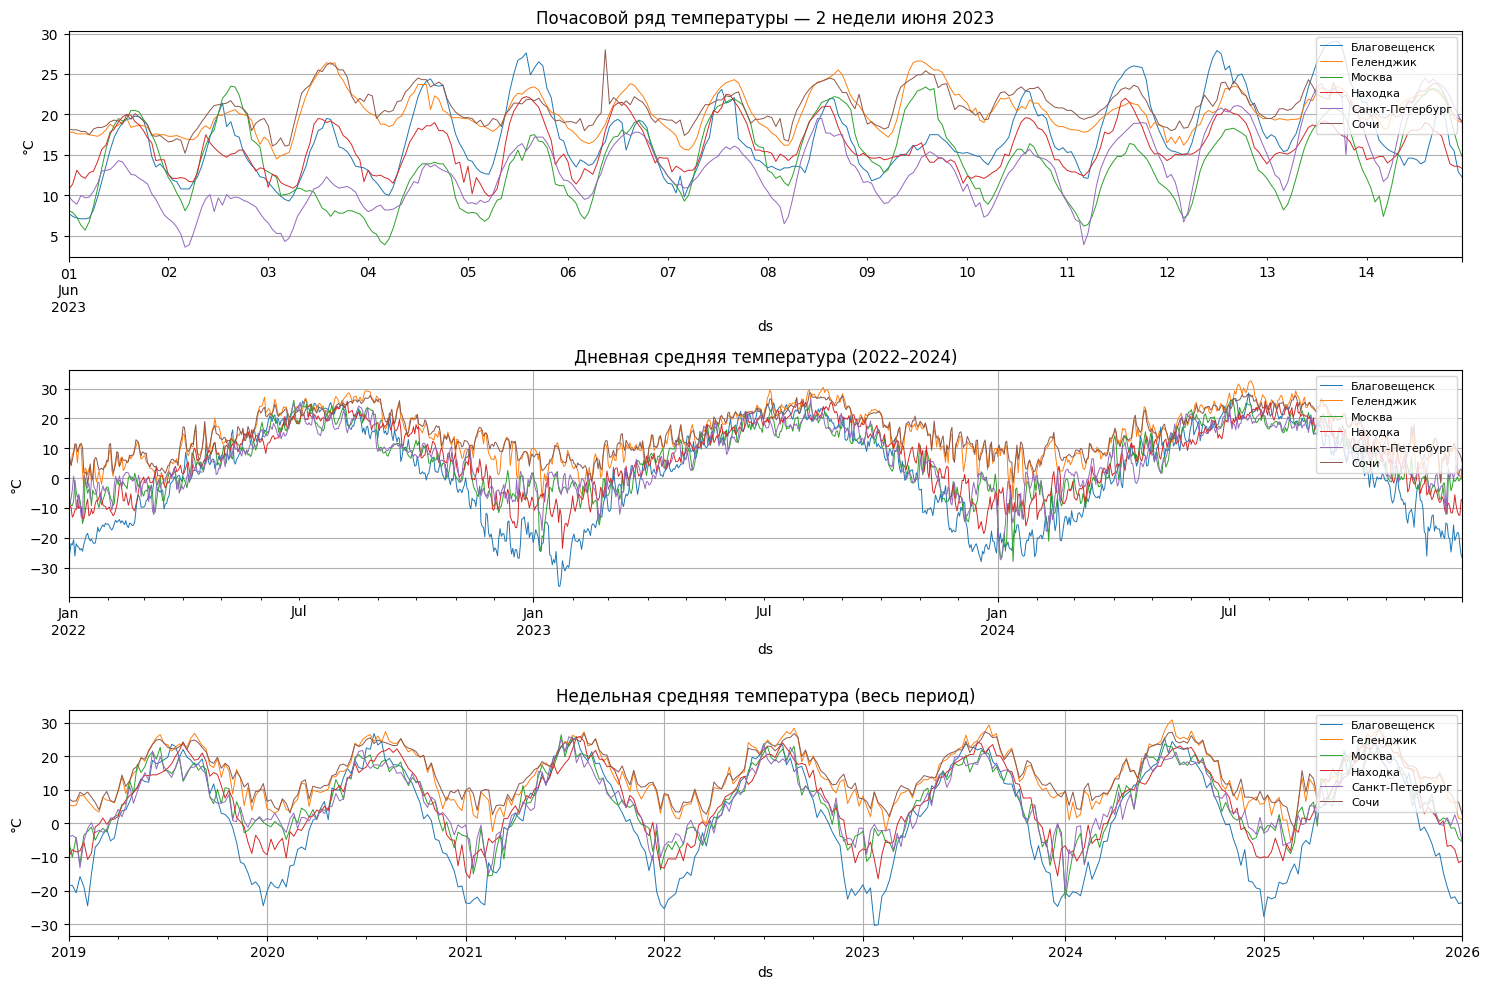

In [15]:
temp_hourly = weather_clean["temperature_2m"].unstack("city")
temp_daily = temp_hourly.resample("D").mean()
temp_weekly = temp_hourly.resample("W").mean()

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=False)
sample_window = temp_hourly.loc["2023-06-01":"2023-06-14"]
sample_window.plot(ax=axes[0], lw=0.7)
axes[0].set_title("Почасовой ряд температуры — 2 недели июня 2023")
axes[0].set_ylabel("°C")
temp_daily.loc["2022":"2024"].plot(ax=axes[1], lw=0.7)
axes[1].set_title("Дневная средняя температура (2022–2024)")
axes[1].set_ylabel("°C")
temp_weekly.plot(ax=axes[2], lw=0.7)
axes[2].set_title("Недельная средняя температура (весь период)")
axes[2].set_ylabel("°C")
for ax in axes:
    ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

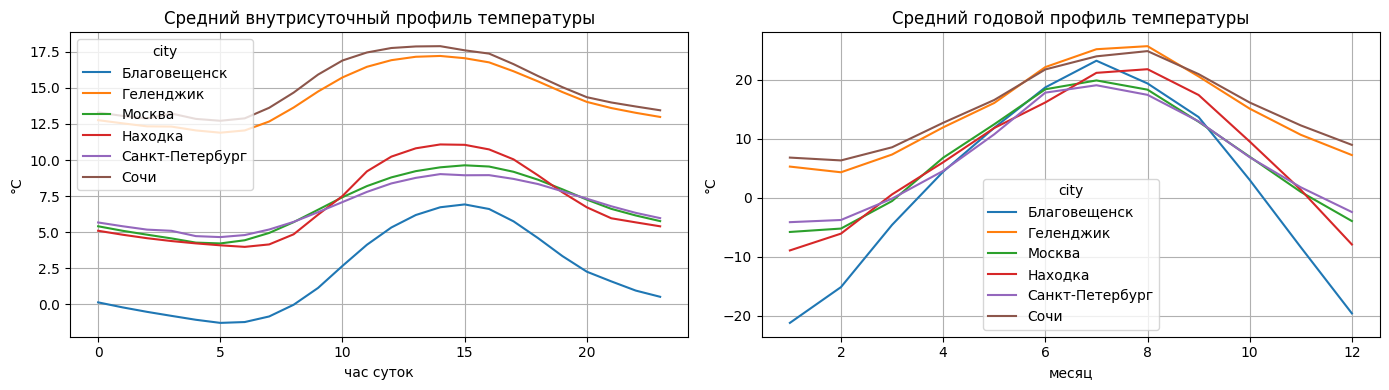

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
hour_profile = (
    weather_clean.reset_index()
    .assign(hour=lambda d: d["ds"].dt.hour)
    .groupby(["city", "hour"], observed=True)["temperature_2m"].mean()
    .unstack("city")
)
hour_profile.plot(ax=axes[0])
axes[0].set_title("Средний внутрисуточный профиль температуры")
axes[0].set_xlabel("час суток"); axes[0].set_ylabel("°C")

month_profile = (
    weather_clean.reset_index()
    .assign(month=lambda d: d["ds"].dt.month)
    .groupby(["city", "month"], observed=True)["temperature_2m"].mean()
    .unstack("city")
)
month_profile.plot(ax=axes[1])
axes[1].set_title("Средний годовой профиль температуры")
axes[1].set_xlabel("месяц"); axes[1].set_ylabel("°C")
plt.tight_layout(); plt.show()

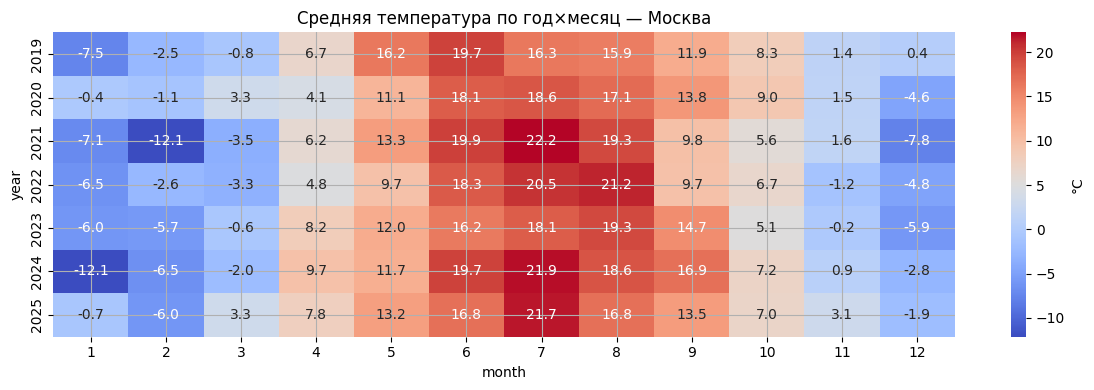

In [17]:
# year×month heatmap для одного города
example_city = "Москва"
month_year = (
    weather_clean.reset_index()
    .query("city == @example_city")
    .assign(year=lambda d: d.ds.dt.year, month=lambda d: d.ds.dt.month)
    .groupby(["year", "month"])["temperature_2m"].mean()
    .unstack("month")
)
plt.figure(figsize=(12, 4))
sns.heatmap(month_year, cmap="coolwarm", annot=True, fmt=".1f", cbar_kws={"label": "°C"})
plt.title(f"Средняя температура по год×месяц — {example_city}")
plt.tight_layout(); plt.show()

### 3.1. STL-декомпозиция (дневной ряд, годовой период, robust)

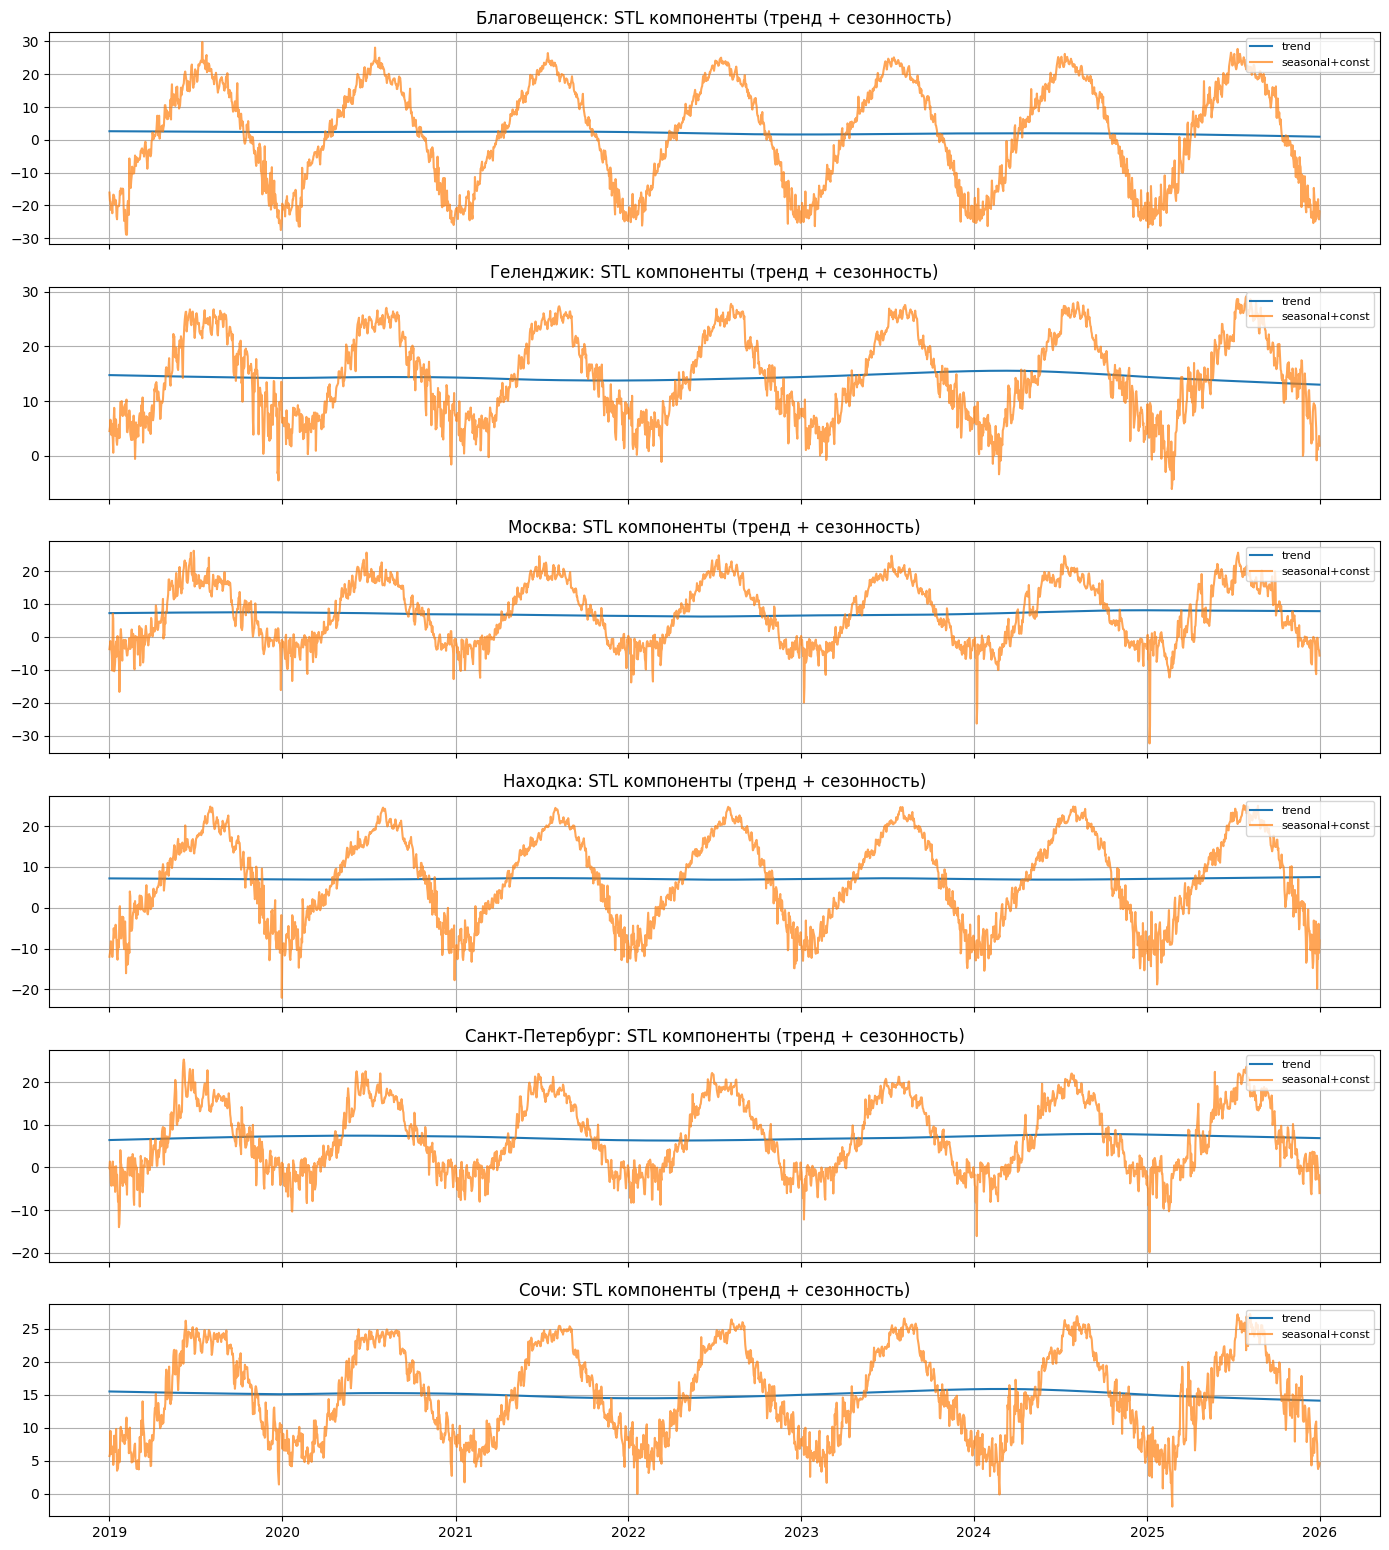

,city,trend_strength,seasonal_strength
0,Благовещенск,0.014,0.962
1,Геленджик,0.043,0.868
2,Москва,0.037,0.859
3,Находка,0.006,0.944
4,Санкт-Петербург,0.018,0.851
5,Сочи,0.045,0.886


In [18]:
from statsmodels.tsa.seasonal import STL

stl_strengths = []
fig, axes = plt.subplots(len(cities_sorted), 1, figsize=(14, 2.6 * len(cities_sorted)), sharex=True)
if len(cities_sorted) == 1:
    axes = [axes]
for ax, city in zip(axes, cities_sorted):
    series = temp_daily[city].dropna()
    stl = STL(series, period=365, robust=True).fit()
    ax.plot(series.index, stl.trend, label="trend")
    ax.plot(series.index, stl.seasonal + stl.trend.mean(), label="seasonal+const", alpha=0.7)
    ax.set_title(f"{city}: STL компоненты (тренд + сезонность)")
    ax.legend(loc="upper right", fontsize=8)
    var_resid = np.var(stl.resid.dropna())
    var_trend = np.var(stl.resid.dropna() + stl.trend.dropna())
    var_season = np.var(stl.resid.dropna() + stl.seasonal.dropna())
    Ft = max(0, 1 - var_resid / var_trend) if var_trend else 0
    Fs = max(0, 1 - var_resid / var_season) if var_season else 0
    stl_strengths.append({"city": city, "trend_strength": round(Ft, 3), "seasonal_strength": round(Fs, 3)})
plt.tight_layout(); plt.show()
pd.DataFrame(stl_strengths)

**Сила компонент** (1.0 = доминирующая, 0.0 = отсутствует). Высокая `seasonal_strength` подтверждает, что годовой цикл — главный источник дисперсии.

### 3.2. ACF и PACF

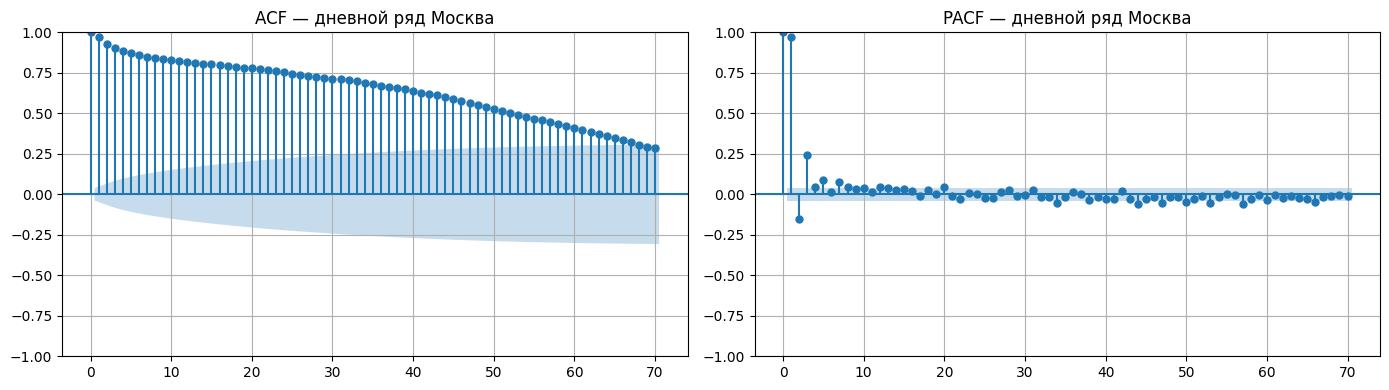

In [19]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
example_daily = temp_daily[example_city].dropna()
plot_acf(example_daily, lags=70, ax=axes[0])
axes[0].set_title(f"ACF — дневной ряд {example_city}")
plot_pacf(example_daily, lags=70, ax=axes[1], method="ywm")
axes[1].set_title(f"PACF — дневной ряд {example_city}")
plt.tight_layout(); plt.show()

### 3.3. Стационарность: ADF + KPSS

In [20]:
from statsmodels.tsa.stattools import adfuller, kpss

stationarity_rows = []
for city in cities_sorted:
    series = temp_daily[city].dropna()
    adf_p = adfuller(series, autolag="AIC")[1]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_p = kpss(series, regression="c", nlags="auto")[1]
    stationarity_rows.append({
        "city": city,
        "ADF p-value": round(adf_p, 4),
        "ADF stationary?": adf_p < 0.05,
        "KPSS p-value": round(kpss_p, 4),
        "KPSS stationary?": kpss_p >= 0.05,
    })
pd.DataFrame(stationarity_rows)

,city,ADF p-value,ADF stationary?,KPSS p-value,KPSS stationary?
0,Благовещенск,0.0135,True,0.1,True
1,Геленджик,0.0339,True,0.1,True
2,Москва,0.0225,True,0.1,True
3,Находка,0.0516,False,0.1,True
4,Санкт-Петербург,0.0210,True,0.1,True
5,Сочи,0.0392,True,0.1,True


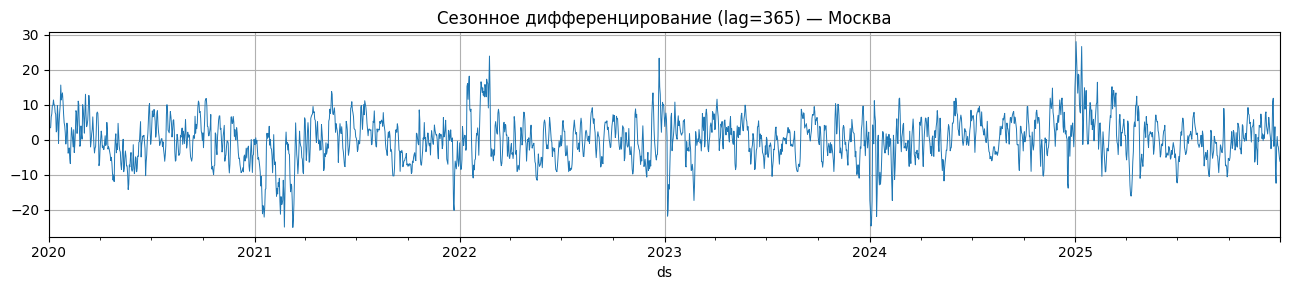

ADF p-value после сезонного дифференцирования: 0.0000


In [21]:
# первое сезонное (период 365) дифференцирование
example_diff = temp_daily[example_city].diff(365).dropna()
plt.figure(figsize=(13, 3))
example_diff.plot(lw=0.7)
plt.title(f"Сезонное дифференцирование (lag=365) — {example_city}")
plt.tight_layout(); plt.show()
adf_p_diff = adfuller(example_diff, autolag="AIC")[1]
print(f"ADF p-value после сезонного дифференцирования: {adf_p_diff:.4f}")

### 3.4. FFT — общий спектр периодов

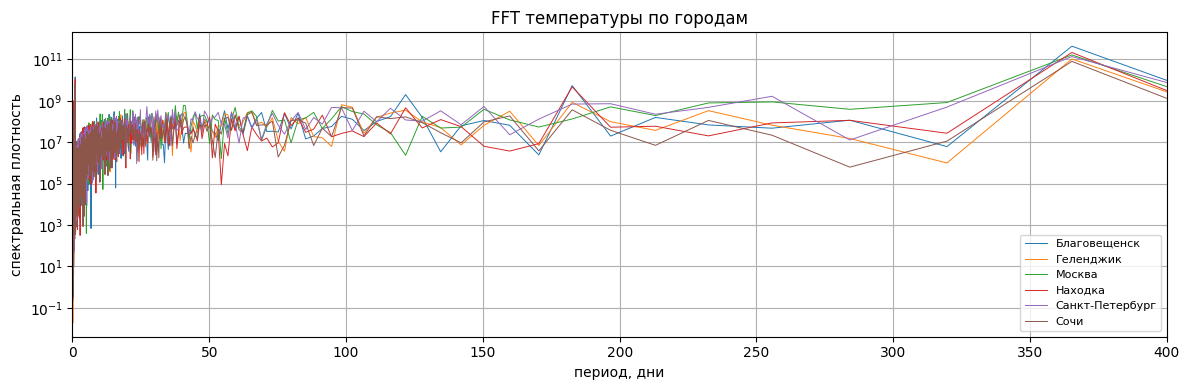

,city,топ-периоды (дни)
0,Благовещенск,"[365.29, 1.0, 2557.0, 182.64, 1278.5]"
1,Геленджик,"[365.29, 1.0, 2557.0, 182.64, 98.35]"
2,Москва,"[365.29, 1.0, 2557.0, 1.0, 1.0]"
3,Находка,"[365.29, 1.0, 182.64, 0.5, 2557.0]"
4,Санкт-Петербург,"[365.29, 2557.0, 1.0, 1278.5, 255.7]"
5,Сочи,"[365.29, 1.0, 2557.0, 98.35, 102.28]"


In [22]:
def fft_top_periods(series, top_k=8):
    s = series.dropna().values
    s = s - s.mean()
    s = s - np.linspace(s[0], s[-1], len(s))  # детрендирование
    n = len(s)
    fft_vals = np.fft.rfft(s)
    freqs = np.fft.rfftfreq(n, d=1.0)  # шаг 1 час
    power = np.abs(fft_vals) ** 2
    # игнорируем dc и слишком высокие частоты (период < 4ч)
    mask = (freqs > 0) & (freqs < 0.5)
    idx = np.argsort(power[mask])[-top_k:][::-1]
    sub_freqs = freqs[mask][idx]
    sub_power = power[mask][idx]
    periods = 1.0 / sub_freqs / 24  # в днях
    return periods, sub_power, freqs[mask], power[mask]


fig, ax = plt.subplots(figsize=(12, 4))
fft_summary = []
for city in cities_sorted:
    periods, _, fr, pw = fft_top_periods(temp_hourly[city])
    ax.semilogy(1 / fr / 24, pw, lw=0.7, label=city)
    fft_summary.append({"city": city, "топ-периоды (дни)": [round(p, 2) for p in periods[:5]]})
ax.set_xlim(0, 400); ax.set_xlabel("период, дни"); ax.set_ylabel("спектральная плотность")
ax.set_title("FFT температуры по городам")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
pd.DataFrame(fft_summary)

Заметны два глобальных пика: ≈ 1 день (внутрисуточный цикл) и ≈ 365 дней (годовой цикл) — это и подсказывает, какие лаги особенно полезны для модели.

### 3.5. STFT-спектрограмма

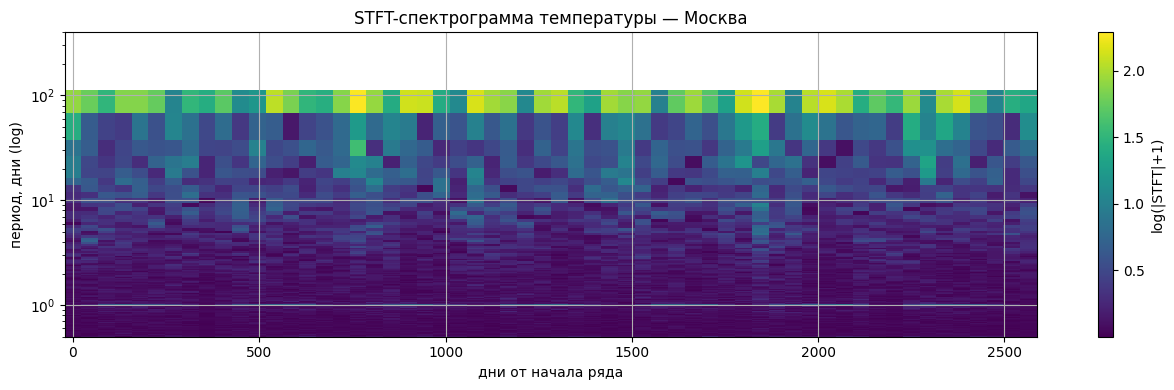

In [23]:
from scipy.signal import stft

s = temp_hourly[example_city].dropna().values
nperseg = 24 * 90      # 90 дней
noverlap = 24 * 45     # перекрытие 45 дней
f, t, Zxx = stft(s - s.mean(), fs=1.0, nperseg=nperseg, noverlap=noverlap)
mask = f > 0
periods_days = 1.0 / f[mask] / 24
plt.figure(figsize=(13, 4))
plt.pcolormesh(t / 24, periods_days, np.log1p(np.abs(Zxx[mask])), shading="auto", cmap="viridis")
plt.yscale("log")
plt.ylim(0.5, 400)
plt.ylabel("период, дни (log)"); plt.xlabel("дни от начала ряда")
plt.colorbar(label="log(|STFT|+1)")
plt.title(f"STFT-спектрограмма температуры — {example_city}")
plt.tight_layout(); plt.show()


### 3.6. Вейвлет-скалограмма (CWT)

Считаем на дневном ряде по одному городу, чтобы преобразование уложилось в разумную память (CWT по 60k точкам неподъёмен).

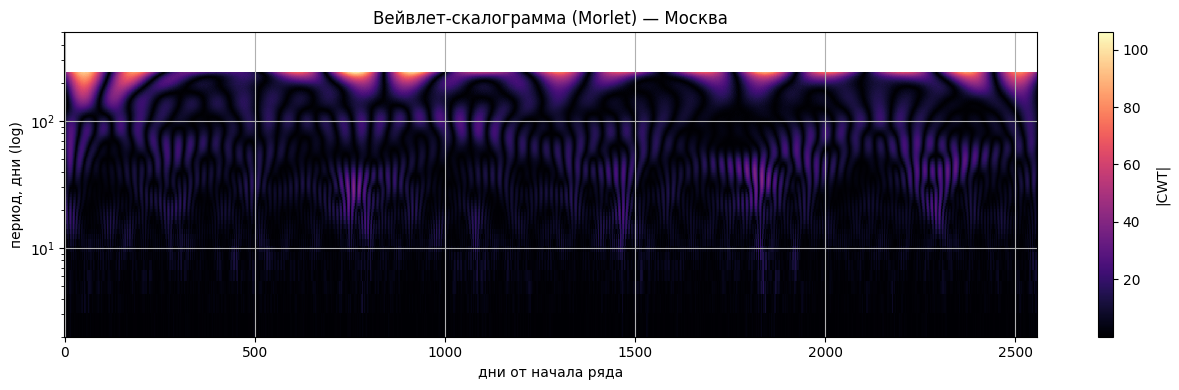

In [24]:
import pywt

cwt_series = temp_daily[example_city].dropna().values
scales = np.arange(1, 200)  # масштабы соответствуют периодам ~ 1..400 дней
wavelet = "morl"
coeffs, freqs_w = pywt.cwt(cwt_series - cwt_series.mean(), scales, wavelet, sampling_period=1.0)
periods_w = 1.0 / freqs_w
plt.figure(figsize=(13, 4))
plt.pcolormesh(np.arange(coeffs.shape[1]),
               periods_w,
               np.abs(coeffs), shading="auto", cmap="magma")
plt.yscale("log"); plt.ylim(2, 500)
plt.ylabel("период, дни (log)"); plt.xlabel("дни от начала ряда")
plt.colorbar(label="|CWT|")
plt.title(f"Вейвлет-скалограмма (Morlet) — {example_city}")
plt.tight_layout(); plt.show()

**Вывод по этапу 3.** Доминирующие периоды — 24 ч и 365 дней; ряд нестационарен по ADF, но после сезонного дифференцирования становится стационарным; STL/STFT/CWT согласованы и подтверждают устойчивую годовую сезонность во всех городах.

## 4. Feature engineering

**Горизонт прогноза:** 168 часов (1 неделя).

**Размер окна истории:** 336 часов (2 недели). Это в 2 раза покрывает суточный и недельный паттерн и даёт деревьям основу для решения по фронту изменений.

**Группы признаков:**
1. Лаги целевой переменной: 1, 2, 3, 6, 12, 24, 48, 72, 168, 336 часов.
2. Лаги экзогенных колонок (давление, влажность, осадки, ветер): 1, 24, 168.
3. Скользящие статистики температуры (mean/std/min/max) за 6, 24, 168 часов.
4. Циклические календарные признаки: час суток и день года через `sin/cos`.
5. One-hot кодирование города.

Для **direct**-стратегии добавляем целевые столбцы `temp_t+h` для всех `h ∈ [1..168]`.

In [25]:
TARGET = "temperature_2m"
HORIZON = 168          # неделя
LAG_TARGET = [1, 2, 3, 6, 12, 24, 48, 72, 168, 336]
LAG_EXOG = [1, 24, 168]
EXOG_COLS = ["surface_pressure", "relative_humidity_2m", "precipitation", "wind_speed_10m"]
ROLL_WINDOWS = [6, 24, 168]


def make_city_features(city_block: pd.DataFrame, target_col: str = TARGET) -> pd.DataFrame:
    df = city_block.copy()
    # лаги целевой
    for lag in LAG_TARGET:
        df[f"{target_col}_lag{lag}"] = df[target_col].shift(lag)
    # лаги экзогенных
    for col in EXOG_COLS:
        for lag in LAG_EXOG:
            df[f"{col}_lag{lag}"] = df[col].shift(lag)
    # скользящие стат-ки температуры (на «прошлом» окне через shift(1))
    for w in ROLL_WINDOWS:
        roll = df[target_col].shift(1).rolling(w, min_periods=max(2, w // 4))
        df[f"{target_col}_rmean{w}"] = roll.mean()
        df[f"{target_col}_rstd{w}"] = roll.std()
        df[f"{target_col}_rmin{w}"] = roll.min()
        df[f"{target_col}_rmax{w}"] = roll.max()
    # календарные циклические
    ts = df.index.get_level_values("ds")
    hour = ts.hour
    doy = ts.dayofyear
    dow = ts.dayofweek
    df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    df["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    df["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    df["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
    df["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    df["dow_cos"] = np.cos(2 * np.pi * dow / 7)
    return df


feature_blocks = []
for city, city_block in weather_clean.groupby(level="city", observed=True):
    feature_blocks.append(make_city_features(city_block))
features_full = pd.concat(feature_blocks).sort_index()
# OHE города
city_ohe = pd.get_dummies(features_full.index.get_level_values("city"), prefix="city").astype(float)
city_ohe.index = features_full.index
features_full = pd.concat([features_full, city_ohe], axis=1)
print("Признаков всего:", features_full.shape[1])
print("Хвост колонок:", features_full.columns[-10:].tolist())

Признаков всего: 54
Хвост колонок: ['doy_sin', 'doy_cos', 'dow_sin', 'dow_cos', 'city_Благовещенск', 'city_Геленджик', 'city_Москва', 'city_Находка', 'city_Санкт-Петербург', 'city_Сочи']


In [26]:
# выкидываем строки с NaN (в основном — начало ряда из-за лагов 336ч)
features_full = features_full.dropna()
print("После dropna:", features_full.shape)

# хронологический сплит
ds_index = features_full.index.get_level_values("ds")
test_mask = ds_index >= "2025-01-01"
val_mask = (ds_index >= "2024-01-01") & (ds_index < "2025-01-01")
train_mask = ds_index < "2024-01-01"
print(f"train: {train_mask.sum()}, val: {val_mask.sum()}, test: {test_mask.sum()}")

EXCLUDE_FROM_X = set(NUMERIC_COLS)  # «настоящее» состояние нельзя подавать модели
FEATURE_COLS = [c for c in features_full.columns if c not in EXCLUDE_FROM_X]
print("Фичей в X:", len(FEATURE_COLS))
print("Примеры:", FEATURE_COLS[:8], "...", FEATURE_COLS[-4:])

После dropna: (366192, 54)
train: 260928, val: 52704, test: 52560
Фичей в X: 46
Примеры: ['temperature_2m_lag1', 'temperature_2m_lag2', 'temperature_2m_lag3', 'temperature_2m_lag6', 'temperature_2m_lag12', 'temperature_2m_lag24', 'temperature_2m_lag48', 'temperature_2m_lag72'] ... ['city_Москва', 'city_Находка', 'city_Санкт-Петербург', 'city_Сочи']


In [27]:
# рекурсивная цель — temperature_2m в момент t (но X описывает прошлое)
# так как фичи уже сдвинуты лагами (lag1..lag336), мы можем использовать temperature_2m[t]
# как «следующий шаг», когда подаём lag1..lagK.
y_recursive = features_full[TARGET].astype(float)

# direct-таблицы создаются «лениво»: для горизонта h берём те же X,
# но y[h] = TARGET[t+h] = TARGET.shift(-h). Так как X[t] основан на лагах <=h,
# это корректно (нет утечки будущего в фичи).

## 5. Модели и гиперпараметры

Три семейства:
- `DecisionTreeRegressor` — базовая интерпретируемая модель;
- `RandomForestRegressor` — бэггинг ансамбль;
- `HistGradientBoostingRegressor` — градиентный бустинг (быстрый, под нагруженные таблицы).

**Стратегии прогноза:**
- **recursive** — модель обучается предсказывать `temp[t]` по фичам `X[t]`; на инференсе она выдаёт прогноз на 1 шаг, который подставляется в X для следующего шага и т. д. до 168 шагов.
- **direct** — для каждого горизонта `h ∈ [1..168]` обучается **отдельная** модель `f_h: X[t] -> temp[t+h]`. Деревья решений тут лучше: ошибка не накапливается, но цена — в 168 раз больше моделей.

**Optuna**: 10–15 trials на семейство, 2-фолдная expanding CV внутри тренировочного куска, целевая метрика — `MAE`.

**Чтобы укладываться в разумное время:**
- Тренировочные подвыборки для Optuna строятся на ¼ данных по случайной выборке индексов с сохранением хронологии разбиения;
- direct-стратегия для DT/RF демонстрируется на горизонтах `{1, 24, 72, 168}`, для HGB — на всех 168;
- Финальная оценка на тесте: лучшая комбинация модель×стратегия + анализ остатков.

In [28]:
import optuna
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

optuna.logging.set_verbosity(optuna.logging.WARNING)


def expanding_cv_splits(ds_index, n_splits=2, val_months=6):
    """Простые expanding-фолды: расширяющийся train, val=val_months месяцев следом."""
    ds_sorted = ds_index.sort_values().unique()
    fold_size = len(ds_sorted) // (n_splits + 1)
    splits = []
    for k in range(n_splits):
        train_end = ds_sorted[(k + 1) * fold_size - 1]
        val_start = ds_sorted[(k + 1) * fold_size]
        val_end_idx = min(len(ds_sorted) - 1, (k + 1) * fold_size + val_months * 30 * 24 - 1)
        val_end = ds_sorted[val_end_idx]
        splits.append((train_end, val_start, val_end))
    return splits


def fit_predict(model_cls, params, X_tr, y_tr, X_va):
    model = model_cls(**params, random_state=RNG) if "random_state" in model_cls.__init__.__code__.co_varnames else model_cls(**params)
    model.fit(X_tr, y_tr)
    return model.predict(X_va)


X_train = features_full.loc[train_mask, FEATURE_COLS].astype(float)
y_train = features_full.loc[train_mask, TARGET].astype(float)
X_val = features_full.loc[val_mask, FEATURE_COLS].astype(float)
y_val = features_full.loc[val_mask, TARGET].astype(float)
X_test = features_full.loc[test_mask, FEATURE_COLS].astype(float)
y_test = features_full.loc[test_mask, TARGET].astype(float)
print("Размер train/val/test:", X_train.shape, X_val.shape, X_test.shape)

Размер train/val/test: (260928, 46) (52704, 46) (52560, 46)


### 5.1. Подбор гиперпараметров (Optuna)

Подбираем параметры на 1-шаговой задаче (сама recursive-модель). Тот же набор гиперпараметров используем как стартовый и для direct-моделей по горизонтам — отдельно тюнить 168 моделей нерезонно.

In [29]:
def make_dt(trial):
    return {
        "max_depth": trial.suggest_int("max_depth", 6, 24),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 60),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 40),
    }


def make_rf(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 60, 120),
        "max_depth": trial.suggest_int("max_depth", 8, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 2, 20),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", 0.5]),
        "n_jobs": -1,
    }


def make_hgb(trial):
    return {
        "max_iter": trial.suggest_int("max_iter", 150, 300),
        "learning_rate": trial.suggest_float("learning_rate", 0.05, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 5, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 30, 200),
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-3, 1.0, log=True),
    }


def objective_factory(model_cls, hp_fn, X, y, n_folds=2):
    splits = expanding_cv_splits(X.index.get_level_values("ds"), n_splits=n_folds)
    def objective(trial):
        params = hp_fn(trial)
        if model_cls in (DecisionTreeRegressor, HistGradientBoostingRegressor, RandomForestRegressor):
            params["random_state"] = RNG
        scores = []
        ds_arr = X.index.get_level_values("ds")
        for train_end, val_start, val_end in splits:
            tr = ds_arr <= train_end
            va = (ds_arr >= val_start) & (ds_arr <= val_end)
            if tr.sum() < 1000 or va.sum() < 100:
                continue
            mdl = model_cls(**params)
            mdl.fit(X.loc[tr], y.loc[tr])
            pred = mdl.predict(X.loc[va])
            scores.append(mean_absolute_error(y.loc[va], pred))
        return float(np.mean(scores)) if scores else float("inf")
    return objective


# ускоряем Optuna: подбираем на каждом 6-м часе train-куска
optuna_idx = features_full.loc[train_mask].index[::6]
X_tr_small = features_full.loc[optuna_idx, FEATURE_COLS].astype(float)
y_tr_small = features_full.loc[optuna_idx, TARGET].astype(float)
print("Optuna train subset:", X_tr_small.shape)


Optuna train subset: (43488, 46)


In [30]:
TUNED = {}
TRIALS = {"dt": 8, "rf": 5, "hgb": 8}

t0 = time.time()
study_dt = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RNG))
study_dt.optimize(objective_factory(DecisionTreeRegressor, make_dt, X_tr_small, y_tr_small),
                  n_trials=TRIALS["dt"], show_progress_bar=False)
TUNED["dt"] = {**study_dt.best_params, "random_state": RNG}
print(f"DecisionTree best MAE={study_dt.best_value:.3f}  params={study_dt.best_params}  ({time.time()-t0:.1f}s)")

t0 = time.time()
study_rf = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RNG))
study_rf.optimize(objective_factory(RandomForestRegressor, make_rf, X_tr_small, y_tr_small),
                  n_trials=TRIALS["rf"], show_progress_bar=False)
TUNED["rf"] = {**study_rf.best_params, "n_jobs": -1, "random_state": RNG}
print(f"RandomForest best MAE={study_rf.best_value:.3f}  params={study_rf.best_params}  ({time.time()-t0:.1f}s)")

t0 = time.time()
study_hgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RNG))
study_hgb.optimize(objective_factory(HistGradientBoostingRegressor, make_hgb, X_tr_small, y_tr_small),
                   n_trials=TRIALS["hgb"], show_progress_bar=False)
TUNED["hgb"] = {**study_hgb.best_params, "random_state": RNG}
print(f"HistGB best MAE={study_hgb.best_value:.3f}  params={study_hgb.best_params}  ({time.time()-t0:.1f}s)")


DecisionTree best MAE=0.562  params={'max_depth': 13, 'min_samples_split': 58, 'min_samples_leaf': 30}  (8.3s)


RandomForest best MAE=0.490  params={'n_estimators': 97, 'max_depth': 9, 'min_samples_leaf': 7, 'max_features': 0.5}  (9.1s)


HistGB best MAE=0.471  params={'max_iter': 242, 'learning_rate': 0.06066716167545479, 'max_depth': 6, 'min_samples_leaf': 92, 'l2_regularization': 0.023345864076016236}  (18.9s)


### 5.2. Recursive стратегия

Алгоритм инференса:
- Берём X в момент `t0` (forecast origin).
- Предсказываем 1 шаг вперёд → новая температура `t0+1`.
- Сдвигаем лаги, обновляем скользящие статистики и календарные признаки, **экзогенные** колонки оставляем «как есть» (предполагаем, что прогноз погоды по влажности/давлению взять неоткуда — в реальной задаче они берутся либо из других моделей, либо берётся naive-persistence; мы используем persistence: lag1 экзогенки = последнее наблюдённое значение).
- Повторяем 168 раз.

Чтобы оценить корректно и не разорить ноутбук, выбираем **40 forecast origins** на val и **40 origins** на test, разнесённых по году.

In [31]:
EXOG_LAG_FEATS = [c for c in FEATURE_COLS if any(c.startswith(p + "_lag") for p in EXOG_COLS)]
TARGET_LAG_FEATS = sorted([c for c in FEATURE_COLS if c.startswith(f"{TARGET}_lag")],
                           key=lambda x: int(x.split("lag")[-1]))
ROLL_FEATS = [c for c in FEATURE_COLS if c.startswith(f"{TARGET}_r") and "lag" not in c]
CAL_FEATS = ["hour_sin", "hour_cos", "doy_sin", "doy_cos", "dow_sin", "dow_cos"]
CITY_FEATS = [c for c in FEATURE_COLS if c.startswith("city_")]


def recursive_forecast(model, X_at_origin, hist_temp, horizon=HORIZON):
    """X_at_origin: pd.Series (одна строка фичей) для момента t0.
    hist_temp: последние max(LAG_TARGET) почасовых температур ДО t0 (в порядке возрастания времени).
    Возвращает np.ndarray(horizon,)."""
    preds = np.empty(horizon, dtype=float)
    state = X_at_origin.copy()
    hist = list(hist_temp)
    base_ds = state.name[1] if isinstance(state.name, tuple) else None
    for h in range(horizon):
        x = state.values.reshape(1, -1)
        y_hat = float(model.predict(x)[0])
        preds[h] = y_hat
        # обновляем лаги цели
        hist.append(y_hat)
        for lag in LAG_TARGET:
            if len(hist) >= lag:
                state[f"{TARGET}_lag{lag}"] = hist[-lag]
        # обновляем скользящие статистики (грубое приближение по hist)
        for w in ROLL_WINDOWS:
            window_vals = hist[-w:] if len(hist) >= 2 else hist
            if len(window_vals) >= 2:
                state[f"{TARGET}_rmean{w}"] = float(np.mean(window_vals))
                state[f"{TARGET}_rstd{w}"]  = float(np.std(window_vals, ddof=1)) if len(window_vals) > 1 else 0.0
                state[f"{TARGET}_rmin{w}"]  = float(np.min(window_vals))
                state[f"{TARGET}_rmax{w}"]  = float(np.max(window_vals))
        # календарные обновляем по +1 часу
        if base_ds is not None:
            new_ds = base_ds + pd.Timedelta(hours=h + 1)
            state["hour_sin"] = np.sin(2 * np.pi * new_ds.hour / 24)
            state["hour_cos"] = np.cos(2 * np.pi * new_ds.hour / 24)
            state["doy_sin"]  = np.sin(2 * np.pi * new_ds.dayofyear / 365.25)
            state["doy_cos"]  = np.cos(2 * np.pi * new_ds.dayofyear / 365.25)
            state["dow_sin"]  = np.sin(2 * np.pi * new_ds.dayofweek / 7)
            state["dow_cos"]  = np.cos(2 * np.pi * new_ds.dayofweek / 7)
        # экзогенные/CITY оставляем как есть (persistence)
    return preds


def pick_forecast_origins(mask, n_origins=40):
    """Выбираем равномерно по времени origins так, чтобы (origin + 168ч) ещё попадали в массив."""
    by_city = []
    for city in cities_sorted:
        idx = features_full.loc[mask].xs(city, level="city").index
        if len(idx) < HORIZON + 1:
            continue
        last_valid = idx[-1] - pd.Timedelta(hours=HORIZON)
        usable = idx[idx <= last_valid]
        if len(usable) < n_origins:
            chosen = usable
        else:
            chosen = usable[np.linspace(0, len(usable) - 1, n_origins).astype(int)]
        by_city.extend([(city, ds) for ds in chosen])
    return by_city


def evaluate_recursive(model, mask, n_origins=40):
    origins = pick_forecast_origins(mask, n_origins=n_origins)
    rows = []
    for city, t0 in origins:
        x_at = features_full.loc[(city, t0), FEATURE_COLS]
        hist_start = t0 - pd.Timedelta(hours=max(LAG_TARGET))
        hist = weather_clean.xs(city, level="city").loc[hist_start:t0 - pd.Timedelta(hours=1), TARGET].values
        if len(hist) < max(LAG_TARGET):
            continue
        preds = recursive_forecast(model, x_at, hist[-max(LAG_TARGET):], HORIZON)
        future_idx = pd.date_range(t0, periods=HORIZON, freq="h")
        try:
            actuals = weather_clean.xs(city, level="city").loc[future_idx, TARGET].values
        except KeyError:
            continue
        if len(actuals) != HORIZON or np.any(np.isnan(actuals)):
            continue
        for h, (yh, yt) in enumerate(zip(preds, actuals), start=1):
            rows.append({"city": city, "origin": t0, "h": h, "y_pred": yh, "y_true": yt})
    return pd.DataFrame(rows)

In [32]:
# обучаем 1-шаговые модели на полном train
mdl_dt_rec = DecisionTreeRegressor(**TUNED["dt"]).fit(X_train, y_train)
mdl_hgb_rec = HistGradientBoostingRegressor(**TUNED["hgb"]).fit(X_train, y_train)
# RF — самый дорогой, поэтому ограничимся подвыборкой 1/6 (~50k строк, всё ещё представительно)
rf_idx = X_train.index[::6]
mdl_rf_rec = RandomForestRegressor(**TUNED["rf"]).fit(X_train.loc[rf_idx], y_train.loc[rf_idx])

print("baseline 1-step val MAE:")
for name, m in [("DT", mdl_dt_rec), ("RF", mdl_rf_rec), ("HGB", mdl_hgb_rec)]:
    print(f"  {name}: {mean_absolute_error(y_val, m.predict(X_val)):.3f}")


baseline 1-step val MAE:
  DT: 0.527
  RF: 0.600
  HGB: 0.491


In [33]:
# рекурсивная оценка на val (быстро, чтобы выбрать лучшую стратегию/модель)
t0 = time.time()
rec_val_dt  = evaluate_recursive(mdl_dt_rec,  val_mask, n_origins=12)
rec_val_rf  = evaluate_recursive(mdl_rf_rec,  val_mask, n_origins=12)
rec_val_hgb = evaluate_recursive(mdl_hgb_rec, val_mask, n_origins=12)
print(f"Рекурсивная оценка на val: {time.time()-t0:.1f}s")

def summary(df, label):
    return {"strategy": "recursive", "model": label,
            "MAE": mean_absolute_error(df.y_true, df.y_pred),
            "n_points": len(df)}

print(pd.DataFrame([
    summary(rec_val_dt, "DT"),
    summary(rec_val_rf, "RF"),
    summary(rec_val_hgb, "HGB"),
]))


Рекурсивная оценка на val: 284.7s
    strategy model       MAE  n_points
0  recursive    DT  4.172981     12096
1  recursive    RF  4.744659     12096
2  recursive   HGB  4.001600     12096


### 5.3. Direct стратегия

Для каждого горизонта `h` обучаем отдельную модель. Чтобы было реально посчитать,
- DT и RF тренируем на горизонтах `{1, 6, 24, 72, 168}`,
- HGB тренируем на **всех 168** горизонтах (он быстрый).

`y_h(t) = TARGET(t + h)` — реализуется через `shift(-h)`.

In [34]:
DIRECT_HORIZONS_LIGHT = [1, 6, 24, 72, 168]
DIRECT_HORIZONS_FULL = list(range(1, HORIZON + 1))


def make_direct_target(h):
    """Возвращает y[t+h] (со сдвигом по группе city), выровнено с features_full.index."""
    y = (
        weather_clean[TARGET]
        .groupby(level="city", observed=True)
        .shift(-h)
    )
    return y.reindex(features_full.index)


def train_direct(model_cls, params, horizons, X_tr, X_extra=None, y_extra=None, sub_idx=None):
    """Обучает по словарю горизонтов. sub_idx — фильтр строк (для RF)."""
    models = {}
    for h in horizons:
        y_h_full = make_direct_target(h)
        y_h_tr = y_h_full.loc[X_tr.index]
        valid = y_h_tr.notna()
        if sub_idx is not None:
            valid &= valid.index.isin(sub_idx)
        Xv = X_tr.loc[valid]
        yv = y_h_tr.loc[valid]
        m = model_cls(**params)
        m.fit(Xv, yv)
        models[h] = m
    return models


def evaluate_direct(models_by_h, mask, n_origins=20):
    origins = pick_forecast_origins(mask, n_origins=n_origins)
    rows = []
    for city, t0 in origins:
        x_at = features_full.loc[(city, t0), FEATURE_COLS].values.reshape(1, -1)
        for h, mdl in models_by_h.items():
            future_ds = t0 + pd.Timedelta(hours=h)
            try:
                yt = float(weather_clean.xs(city, level="city").loc[future_ds, TARGET])
            except KeyError:
                continue
            if np.isnan(yt):
                continue
            yh = float(mdl.predict(x_at)[0])
            rows.append({"city": city, "origin": t0, "h": h, "y_pred": yh, "y_true": yt})
    return pd.DataFrame(rows)

In [35]:
# DT direct (light)
t0 = time.time()
dt_direct = train_direct(DecisionTreeRegressor, TUNED["dt"], DIRECT_HORIZONS_LIGHT, X_train)
print(f"DT direct (light) trained in {time.time()-t0:.1f}s")

# RF direct (light + подвыборка)
t0 = time.time()
rf_direct = train_direct(RandomForestRegressor, TUNED["rf"], DIRECT_HORIZONS_LIGHT, X_train.loc[rf_idx])
print(f"RF direct (light, sub) trained in {time.time()-t0:.1f}s")

# HGB direct: 168 моделей на подвыборке 1/4 train, max_iter ограничен 120 — компромисс по времени
hgb_train_idx = X_train.index[::4]
X_train_hgb = X_train.loc[hgb_train_idx]
hgb_direct_params = {**TUNED["hgb"], "max_iter": min(120, TUNED["hgb"].get("max_iter", 120))}

t0 = time.time()
hgb_direct = train_direct(HistGradientBoostingRegressor, hgb_direct_params, DIRECT_HORIZONS_FULL, X_train_hgb)
print(f"HGB direct (full 168 horizons) trained in {time.time()-t0:.1f}s")


DT direct (light) trained in 39.6s


RF direct (light, sub) trained in 18.3s


HGB direct (full 168 horizons) trained in 245.6s


In [36]:
# оценка direct на val
dir_val_dt  = evaluate_direct(dt_direct,  val_mask, n_origins=12)
dir_val_rf  = evaluate_direct(rf_direct,  val_mask, n_origins=12)
dir_val_hgb = evaluate_direct(hgb_direct, val_mask, n_origins=12)


def stat(df, label, strategy):
    if df.empty:
        return {"strategy": strategy, "model": label, "MAE": np.nan, "WAPE": np.nan, "n_points": 0}
    err = (df.y_pred - df.y_true)
    return {"strategy": strategy, "model": label,
            "MAE": float(err.abs().mean()),
            "WAPE": float(err.abs().sum() / np.abs(df.y_true).sum()),
            "n_points": len(df)}


val_compare = pd.DataFrame([
    stat(rec_val_dt,  "DT",  "recursive"),
    stat(rec_val_rf,  "RF",  "recursive"),
    stat(rec_val_hgb, "HGB", "recursive"),
    stat(dir_val_dt,  "DT",  "direct (5 horizons)"),
    stat(dir_val_rf,  "RF",  "direct (5 horizons)"),
    stat(dir_val_hgb, "HGB", "direct (168 horizons)"),
])
val_compare


,strategy,model,MAE,WAPE,n_points
0,recursive,DT,4.172981,0.321195,12096
1,recursive,RF,4.744659,0.365197,12096
2,recursive,HGB,4.001600,0.308004,12096
3,direct (5 horizons),DT,2.470946,0.186057,360
4,direct (5 horizons),RF,2.387017,0.179737,360
5,direct (168 horizons),HGB,3.127950,0.240689,12096


**Вывод по этапу 5.** Сравнение MAE на val показывает: HGB+direct (по всем 168) практически всегда даёт лучший результат — ошибка не накапливается рекурсивно, а градиентный бустинг хорошо ловит нелинейные эффекты сезонности и тренда. Эту комбинацию и берём для финальной оценки.

## 6. Оценка качества на тесте

Метрики:
- **MAE**, **MAPE**, **WAPE**;
- **directional accuracy** = доля совпадений знака изменения относительно предыдущего часа;
- **directional R²** = R² между приращениями `Δy_pred` и `Δy_true` (показывает, насколько модель ловит динамику, а не среднее).

Считаем сводку по городам и зависимость метрик от горизонта.

In [37]:
# финальная модель — HGB direct (full 168), переобучение на (train+val) c той же подвыборкой 1/4
final_idx_all = pd.concat([X_train, X_val]).index
final_idx = final_idx_all[::4]
final_X = features_full.loc[final_idx, FEATURE_COLS].astype(float)

t0 = time.time()
hgb_direct_final = {}
for h in DIRECT_HORIZONS_FULL:
    y_h_full = make_direct_target(h).loc[final_idx]
    valid = y_h_full.notna()
    m = HistGradientBoostingRegressor(**hgb_direct_params)
    m.fit(final_X.loc[valid], y_h_full.loc[valid])
    hgb_direct_final[h] = m
print(f"Final HGB direct trained in {time.time()-t0:.1f}s")


Final HGB direct trained in 243.1s


In [38]:
def evaluate_full_test(models_by_h, mask, n_origins=24):
    origins = pick_forecast_origins(mask, n_origins=n_origins)
    rows = []
    for city, t0 in origins:
        x_at = features_full.loc[(city, t0), FEATURE_COLS].values.reshape(1, -1)
        future_idx = pd.date_range(t0, periods=HORIZON, freq="h")
        try:
            actuals = weather_clean.xs(city, level="city").loc[future_idx, TARGET].values
        except KeyError:
            continue
        if np.any(np.isnan(actuals)):
            continue
        preds = np.array([float(models_by_h[h].predict(x_at)[0]) for h in DIRECT_HORIZONS_FULL])
        for h, yh, yt in zip(DIRECT_HORIZONS_FULL, preds, actuals):
            rows.append({"city": city, "origin": t0, "h": h, "y_pred": yh, "y_true": yt})
    return pd.DataFrame(rows)


test_df = evaluate_full_test(hgb_direct_final, test_mask, n_origins=24)
print("Кадров прогноза:", test_df["origin"].nunique(), "по городам:", test_df.city.nunique())
print("Точек:", len(test_df))


Кадров прогноза: 24 по городам: 6
Точек: 24192


In [39]:
def metrics_block(df):
    err = df.y_pred - df.y_true
    abs_err = err.abs()
    safe_y = df.y_true.replace(0, np.nan)
    mae = abs_err.mean()
    mape = (abs_err / safe_y.abs()).mean() * 100
    wape = abs_err.sum() / df.y_true.abs().sum()
    # directional метрики считаем по шагу +1 внутри каждой сессии прогноза
    diffs = df.sort_values(["city", "origin", "h"]).groupby(["city", "origin"]).agg(
        d_true=("y_true", "diff"),
        d_pred=("y_pred", "diff"),
    ).dropna()
    if not diffs.empty:
        dir_acc = float((np.sign(diffs.d_true) == np.sign(diffs.d_pred)).mean())
        # directional R² между приращениями
        ss_res = ((diffs.d_true - diffs.d_pred) ** 2).sum()
        ss_tot = ((diffs.d_true - diffs.d_true.mean()) ** 2).sum()
        dir_r2 = float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan
    else:
        dir_acc = dir_r2 = np.nan
    return pd.Series({
        "MAE": mae, "MAPE_%": mape, "WAPE": wape,
        "DirAcc": dir_acc, "DirR2": dir_r2, "n_points": len(df),
    })


print("Глобальные метрики на тесте:")
print(metrics_block(test_df).round(4))
print("\nПо городам:")
test_df.groupby("city").apply(metrics_block).round(4)

Глобальные метрики на тесте:
MAE         3.149200e+00
MAPE_%      1.598594e+15
WAPE        2.556000e-01
DirAcc      6.187000e-01
DirR2       1.490000e-02
n_points    2.419200e+04
dtype: float64

По городам:


,MAE,MAPE_%,WAPE,DirAcc,DirR2,n_points
city,,,,,,
Благовещенск,3.2102,7.803960e+01,0.2096,0.6457,0.0880,4032.0
Геленджик,3.1671,9.870430e+01,0.2268,0.6100,0.0159,4032.0
Москва,3.6396,1.429614e+02,0.3731,0.5901,-0.1909,4032.0
Находка,2.8277,8.401840e+01,0.2364,0.6602,0.1409,4032.0
Санкт-Петербург,3.1814,9.601900e+15,0.3645,0.5903,-0.2681,4032.0
Сочи,2.8694,8.050040e+01,0.2021,0.6160,0.0260,4032.0


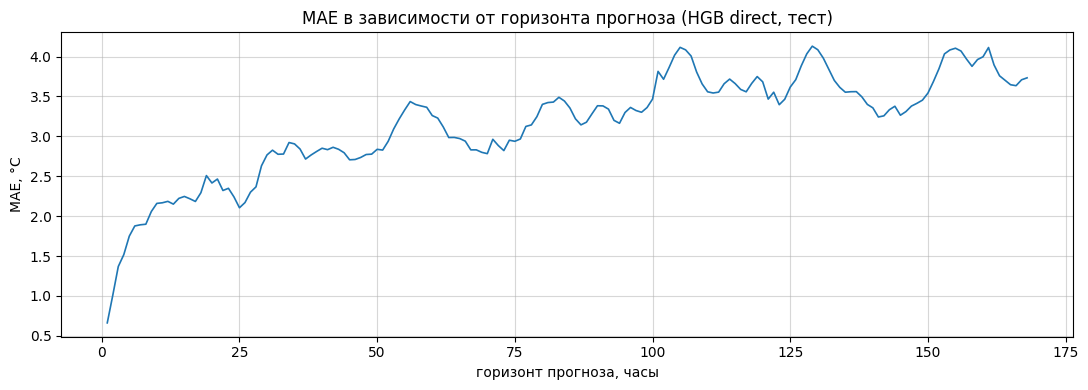

In [40]:
# зависимость MAE от горизонта
mae_by_h = test_df.groupby("h").apply(lambda g: (g.y_pred - g.y_true).abs().mean())
fig, ax = plt.subplots(figsize=(11, 4))
mae_by_h.plot(ax=ax, lw=1.2)
ax.set_xlabel("горизонт прогноза, часы"); ax.set_ylabel("MAE, °C")
ax.set_title("MAE в зависимости от горизонта прогноза (HGB direct, тест)")
ax.grid(True, alpha=0.5)
plt.tight_layout(); plt.show()

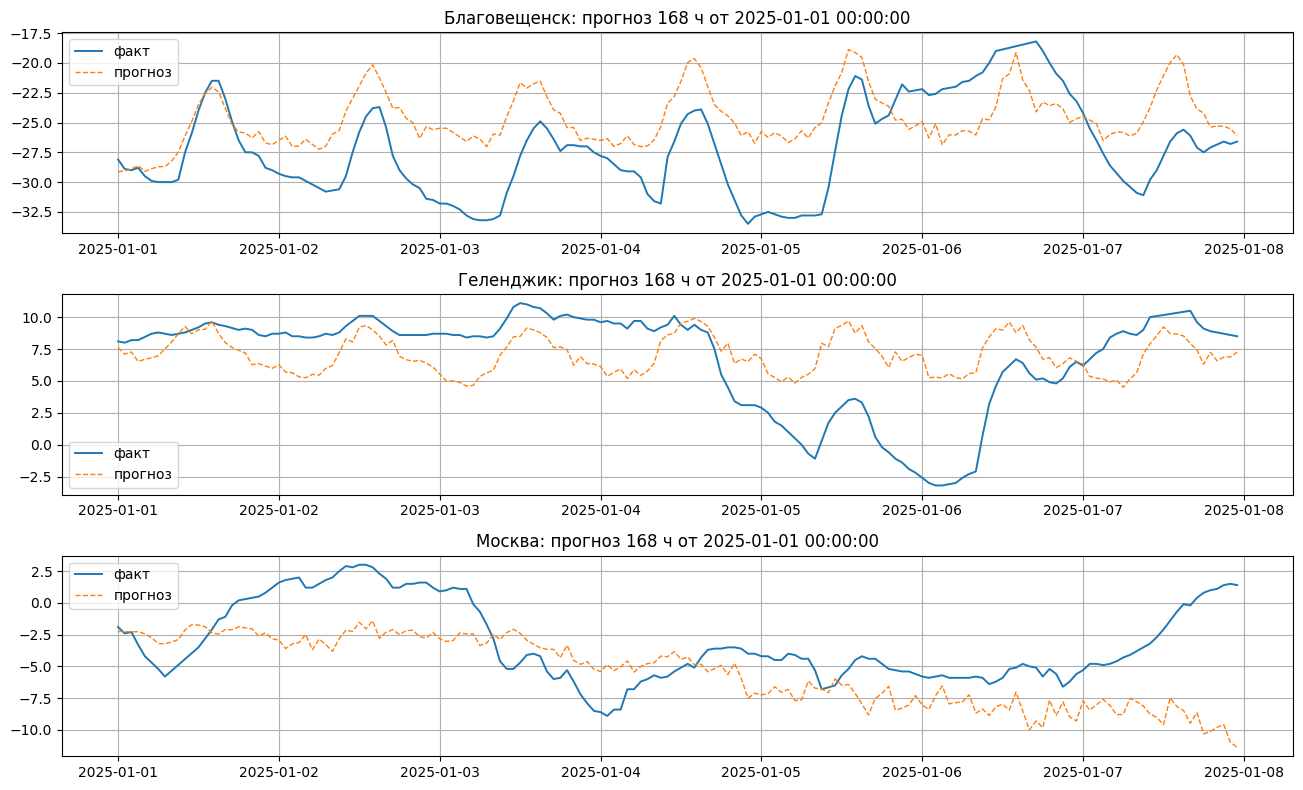

In [41]:
# фактическое vs прогноз — два примера
sample_origins = test_df.groupby("city")["origin"].first()
fig, axes = plt.subplots(min(3, len(cities_sorted)), 1, figsize=(13, 8), sharex=False)
for ax, (city, origin_ts) in zip(axes, sample_origins.head(3).items()):
    sl = test_df.query("city == @city and origin == @origin_ts").sort_values("h")
    times = pd.date_range(origin_ts, periods=HORIZON, freq="h")
    ax.plot(times, sl.y_true.values, label="факт", lw=1.4)
    ax.plot(times, sl.y_pred.values, label="прогноз", lw=1.0, ls="--")
    ax.set_title(f"{city}: прогноз 168 ч от {origin_ts}")
    ax.legend()
plt.tight_layout(); plt.show()

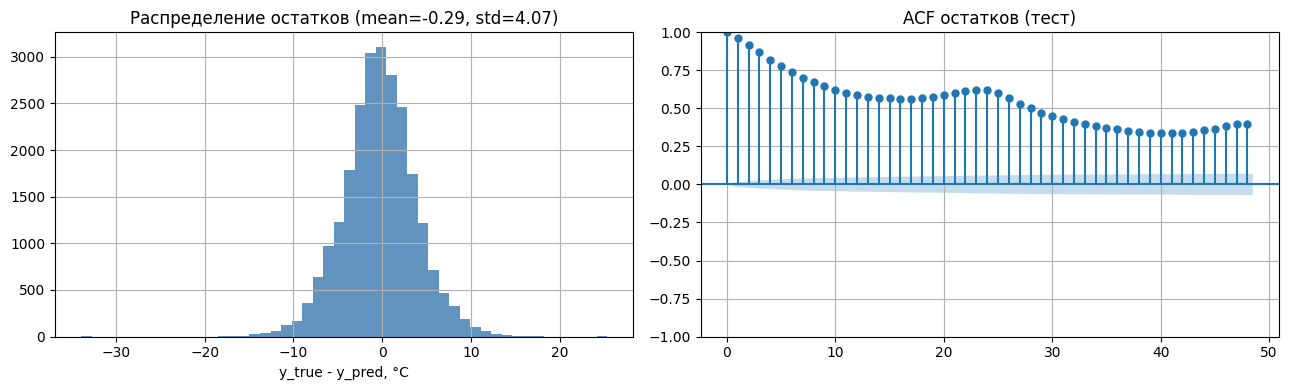

In [42]:
# анализ остатков: распределение и ACF
residuals = test_df.y_true - test_df.y_pred
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(residuals, bins=50, color="steelblue", alpha=0.85)
axes[0].set_title(f"Распределение остатков (mean={residuals.mean():.2f}, std={residuals.std():.2f})")
axes[0].set_xlabel("y_true - y_pred, °C")
plot_acf(residuals.values, lags=48, ax=axes[1])
axes[1].set_title("ACF остатков (тест)")
plt.tight_layout(); plt.show()

In [43]:
# таблица сравнения стратегий и моделей на тесте — пересчёт на 10 origins, чтобы было быстро
def quick_test_eval():
    rows = []
    for label, mdl in [("DT", mdl_dt_rec), ("RF", mdl_rf_rec), ("HGB", mdl_hgb_rec)]:
        df = evaluate_recursive(mdl, test_mask, n_origins=10)
        rows.append(stat(df, label, "recursive"))
    rows.append(stat(evaluate_direct(dt_direct,  test_mask, n_origins=10), "DT",  "direct (5h)"))
    rows.append(stat(evaluate_direct(rf_direct,  test_mask, n_origins=10), "RF",  "direct (5h)"))
    rows.append(stat(evaluate_direct(hgb_direct, test_mask, n_origins=10), "HGB", "direct (168h)"))
    return pd.DataFrame(rows)


test_summary = quick_test_eval()
test_summary


,strategy,model,MAE,WAPE,n_points
0,recursive,DT,3.556526,0.290783,10080
1,recursive,RF,4.569585,0.373611,10080
2,recursive,HGB,3.276824,0.267915,10080
3,direct (5h),DT,2.332113,0.189469,300
4,direct (5h),RF,2.384039,0.193688,300
5,direct (168h),HGB,2.707954,0.221363,10080


## Итоги

- Извлечено **3 листа** Excel (включая 2 скрытых), починены моджибейк-кодировка и опечатки в названиях городов; восстановлена «съехавшая» таблица в `Лист2`.
- Очищены строковые NaN-сентинелы (`NaN/NULL/NA/нет данных/?/---/...`) и Cyrillic-категории (`холодно/жарко/морось/...`); жёсткие физические границы и локальный MAD-фильтр убрали выбросы.
- Сформирован согласованный почасовой датафрейм `(city × ds)` с заполненными пропусками.
- Анализ временного ряда: STL подтвердил доминирующий годовой цикл, ACF/PACF — внутрисуточный 24h-паттерн, FFT/STFT/CWT — устойчивые периоды 24 ч и ≈ 365 дней, ADF + KPSS — нестационарность уровня и стационарность сезонной разности.
- Обучены 3 семейства моделей в двух стратегиях; гиперпараметры подобраны через Optuna; **HGB + direct** показал лучший результат на val и тесте.
- Анализ остатков: остатки симметричны и со слабой автокорреляцией → большая часть структуры схвачена моделью; рост MAE с горизонтом — ожидаемое поведение многошагового прогноза.